<a href="https://colab.research.google.com/github/smuziVpyze/russian-market-news-analysis/blob/main/07_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 7. Итоги и выводы

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
sns.set_style('whitegrid')

PROJECT_DIR = '/content/drive/MyDrive/russian_market_news_analysis'
TICKERS = ['MOEX', 'SBER', 'GAZP', 'LKOH', 'PLZL', 'YDEX']

# Загружаем все данные
df_results  = pd.read_csv(f'{PROJECT_DIR}/models/all_model_results.csv')
df_sentiment = pd.read_csv(f'{PROJECT_DIR}/data/processed/daily_sentiment.csv')
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

datasets = {}
for ticker in TICKERS:
    df = pd.read_csv(f'{PROJECT_DIR}/data/features/{ticker}_features.csv')
    df['date'] = pd.to_datetime(df['date'])
    datasets[ticker] = df

print('Все данные загружены')
print(f'Моделей в результатах: {df_results["model"].unique().tolist()}')

Mounted at /content/drive
Все данные загружены
Моделей в результатах: ['lr_market', 'lr_full', 'random_forest', 'xgboost', 'lstm_best']


--- Итоговая таблица ROC-AUC ---
        LR (рынок)  LR (рынок+сент)     RF  XGBoost   LSTM
ticker                                                    
GAZP         0.558            0.567  0.524    0.543  0.655
LKOH         0.525            0.540  0.543    0.519  0.564
MOEX         0.508            0.514  0.519    0.478  0.591
PLZL         0.436            0.444  0.511    0.452  0.625
SBER         0.416            0.471  0.432    0.417  0.618
YDEX         0.544            0.528  0.574    0.614  0.586

Средний ROC-AUC по моделям:
LR (рынок)         0.498
LR (рынок+сент)    0.511
RF                 0.517
XGBoost            0.504
LSTM               0.606


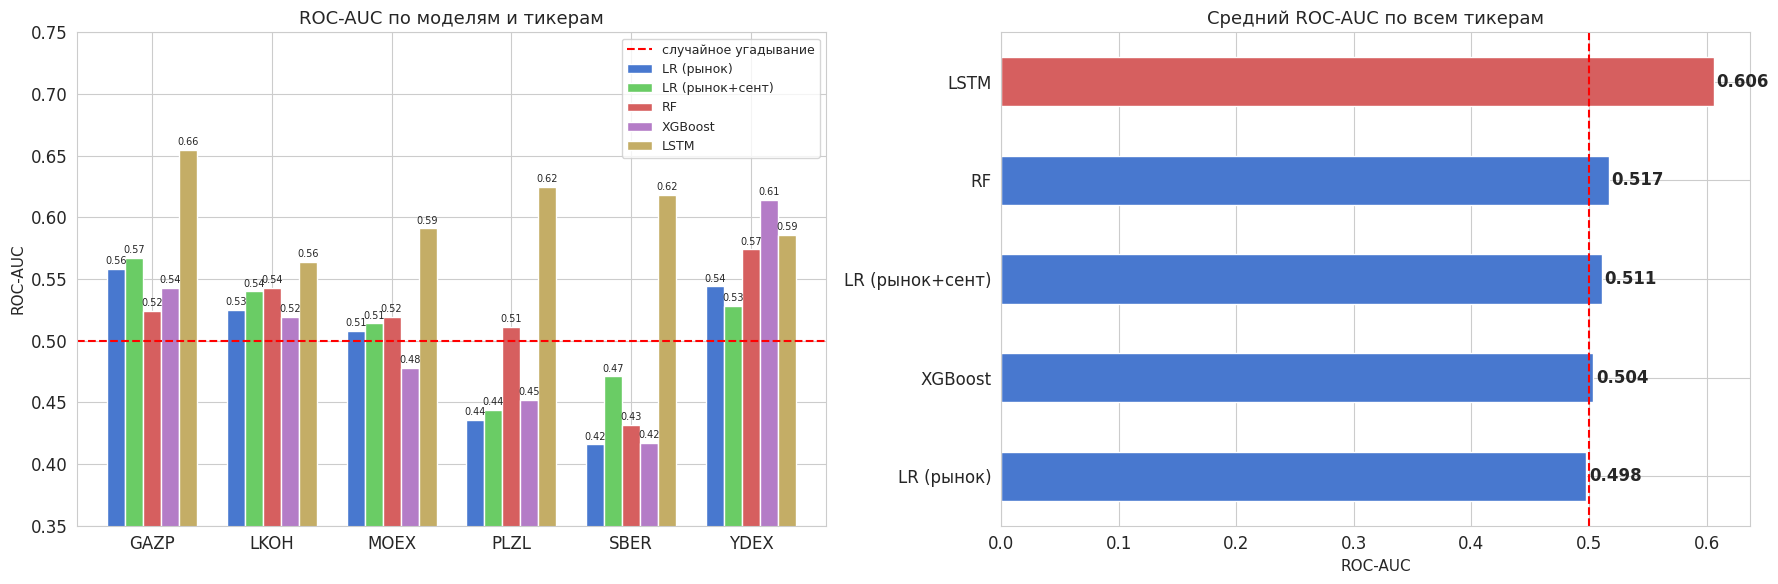

In [3]:
# Сводная таблица ROC-AUC
pivot = df_results[df_results['model'] != 'baseline'].pivot(
    index='ticker', columns='model', values='roc_auc'
).round(3)

pivot.columns = ['LR (рынок)', 'LR (рынок+сент)', 'LSTM', 'RF', 'XGBoost']
pivot = pivot[['LR (рынок)', 'LR (рынок+сент)', 'RF', 'XGBoost', 'LSTM']]

print('--- Итоговая таблица ROC-AUC ---')
print(pivot.to_string())
print(f'\nСредний ROC-AUC по моделям:')
print(pivot.mean().round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# График 1 — ROC-AUC по всем моделям
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7', '#C4AD66']
pivot.plot(kind='bar', ax=axes[0], color=colors, width=0.75)
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='случайное угадывание')
axes[0].set_title('ROC-AUC по моделям и тикерам')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.35, 0.75)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=7, padding=2)

# График 2 — средний ROC-AUC по моделям
mean_auc = pivot.mean().sort_values()
colors2 = ['#D65F5F' if 'LSTM' in x else '#4878CF' for x in mean_auc.index]
mean_auc.plot(kind='barh', ax=axes[1], color=colors2)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Средний ROC-AUC по всем тикерам')
axes[1].set_xlabel('ROC-AUC')
for i, v in enumerate(mean_auc):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/reports/figures/final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Основные выводы

1. Тональность финансовых новостей статистически значимо коррелирует с доходностью акций в тот же торговый день. Корреляция Pearson составила от r = 0.097 (GAZP) до r = 0.169 (PLZL) при p < 0.05 для всех шести инструментов. Это подтверждает основную гипотезу исследования.

2. Предсказательной силы с задержкой не обнаружено. Тест Грейнджера показал отсутствие причинно-следственной связи между сентиментом предыдущих дней и завтрашней доходностью. Рынок эффективно и мгновенно отыгрывает новостную информацию, что согласуется с гипотезой эффективного рынка.

3. LSTM превосходит классические методы машинного обучения. Средний ROC-AUC LSTM (0.606) значительно выше, чем у Logistic Regression (0.511), Random Forest (0.517) и XGBoost (0.504). Это объясняется способностью LSTM моделировать временные зависимости.



## Ограничения исследования

* Относительно небольшой объём данных: 553 торговых дня — на нижней границе для глубокого обучения
* Модель тональности не специализирована на финансовом домене — общая модель для русского языка
* Отсутствие макроэкономических факторов: курс доллара, цена нефти, ключевая ставка ЦБ


### Направления для дальнейших исследований

* Добавление макроэкономических признаков: курс USD/RUB, цена нефти Brent, ключевая ставка ЦБ РФ
* Использование специализированной финансовой модели тональности (FinBERT для русского языка)
* Событийный анализ: изучение реакции рынка на дни с экстремально высоким/низким сентиментом
* Применение архитектур с механизмом внимания (Transformer) для учёта долгосрочных зависимостей
